<a href="https://colab.research.google.com/github/Virbeau/Projet_ML/blob/main/Application_II_Repair_Allocation_Networks_FULL_finite_horizon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Application II — Repair Allocation on Networks (Node-based Reliability)

This notebook is a **reference implementation** for the *Repair Allocation* benchmark (Application II).

We model a network \(N=(V,E,T)\) where:
- **Nodes** represent services/components (microservices, VMs, switches, etc.).
- **Edges** represent dependencies or connectivity.
- **Terminals** \(T\subset V\) are critical nodes (e.g., Client / DB) assumed **always available**.

Non-terminal nodes can **fail** and be **repaired** over discrete time.  
We choose a repair allocation \(\pi\) under a budget constraint to **minimize the probability of reaching a system failure state** within a finite horizon \(H\).

Pedagogical goals:
1. Build \(\phi(X)\) from **network reliability criteria** (connectivity, path length, largest component, etc.).
2. Build the exact Markov chain on \(2^{|V_R|}\) states (small networks).
3. Compute **hitting probabilities** and solve a baseline optimization via **projected gradient descent**.
4. Visualize repair policies directly **on the network graph**.


In [ ]:
# --- Imports (standard, student-friendly) ---
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)


## 1) Network model and notations

We work with:
- \(V\): nodes
- \(E\): edges
- \(T\subset V\): terminals (always UP)
- \(V_R = V\setminus T\): repairable nodes

A system state is a binary vector \(X\in\{0,1\}^{|V_R|}\):
- \(X_v=1\): node is UP
- \(X_v=0\): node is DOWN

Given \(X\), the **residual network** is obtained by removing failed nodes in \(V_R\) (and their incident edges).


In [ ]:
# --- Utilities: reproducible layout + nice network plots ---

def get_layout(G, seed=0):
    # Deterministic-ish layout for consistent plots
    return nx.spring_layout(G, seed=seed)

def draw_network_base(G, terminals, ax=None, title=None, seed=0):
    if ax is None:
        ax = plt.gca()
    pos = get_layout(G, seed=seed)
    # Default colors: avoid hard-coding custom colors; rely on defaults.
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.6)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9)
    # Terminals: draw with a distinctive shape by using node_size and edgecolors
    all_nodes = list(G.nodes())
    term_set = set(terminals)
    non_terms = [v for v in all_nodes if v not in term_set]
    nx.draw_networkx_nodes(G, pos, nodelist=non_terms, ax=ax, node_size=450, linewidths=1.0)
    nx.draw_networkx_nodes(G, pos, nodelist=list(term_set), ax=ax, node_size=650, linewidths=2.0)
    ax.set_axis_off()
    if title:
        ax.set_title(title)
    return pos

def draw_policy_on_network(G, terminals, pi_by_node, ax=None, title=None, seed=0):
    """Overlay repair allocation π on nodes:
    - node size proportional to π
    - terminals highlighted
    """
    if ax is None:
        ax = plt.gca()
    pos = get_layout(G, seed=seed)
    all_nodes = list(G.nodes())
    term_set = set(terminals)
    non_terms = [v for v in all_nodes if v not in term_set]

    # Sizes: base + scale * π (clip for readability)
    pis = np.array([pi_by_node.get(v, 0.0) for v in non_terms], dtype=float)
    base = 350.0
    scale = 2500.0
    sizes_non = base + scale * pis

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.5)
    # Use default colormap; do not hard-code specific colors
    nodes = nx.draw_networkx_nodes(
        G, pos, nodelist=non_terms, node_size=sizes_non, ax=ax,
        node_color=pis, cmap=plt.cm.viridis, linewidths=1.0
    )
    nx.draw_networkx_nodes(G, pos, nodelist=list(term_set), ax=ax, node_size=700, linewidths=2.0)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9)
    plt.colorbar(nodes, ax=ax, fraction=0.046, pad=0.04, label="π (repair allocation)")
    ax.set_axis_off()
    if title:
        ax.set_title(title)
    return pos


## 2) Network topologies (benchmark catalog)

We want a small but diverse set of topologies.  
To keep the Markov chain exact, we will typically use **|V_R| ≤ 10**.

We provide a catalog of small graphs:
- line / chain
- ring
- star
- two parallel paths
- small grid (2×3)
- microservice DAG (toy)

Each topology comes with a default set of terminals \(T\).


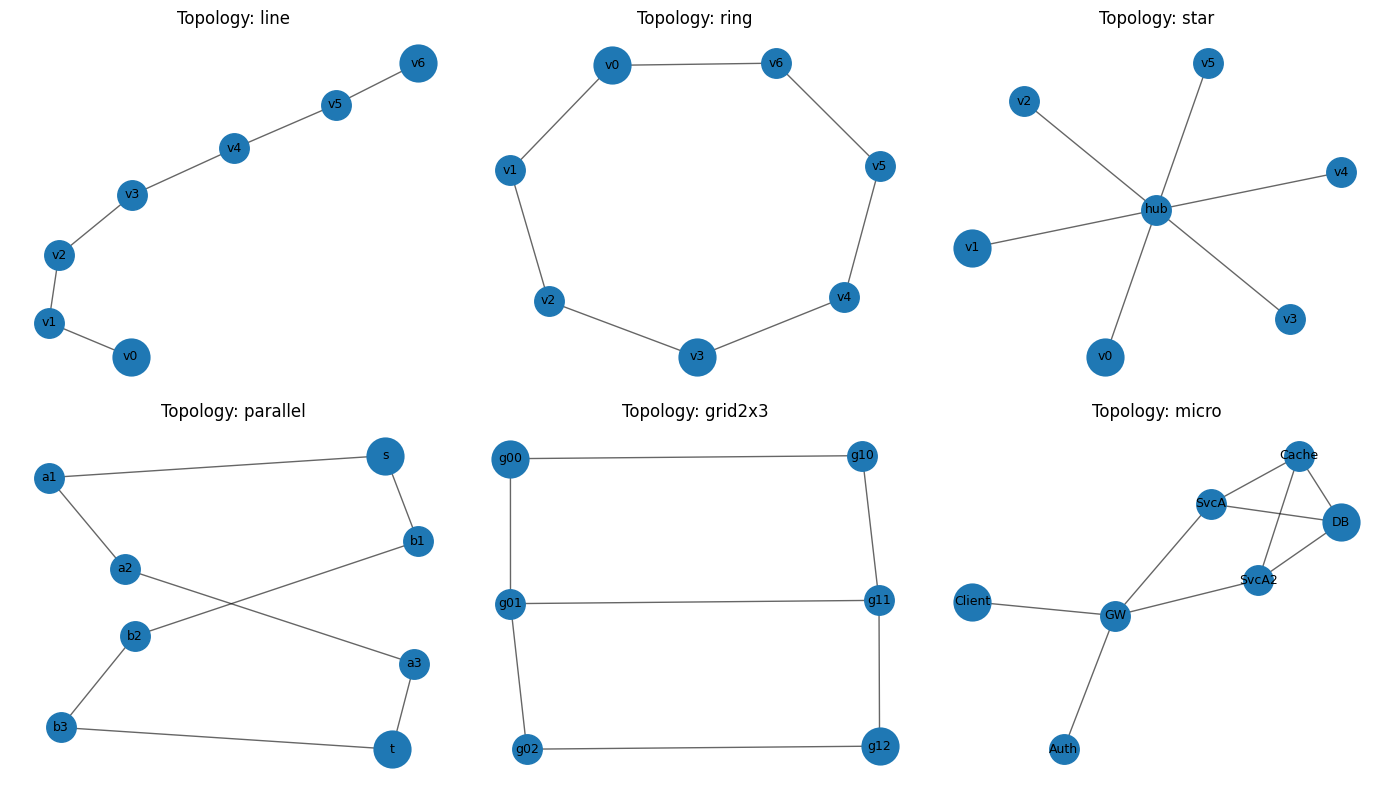

In [ ]:
# --- Topology generators ---

def topo_line(n=6):
    # Nodes labeled as strings for readability
    nodes = [f"v{i}" for i in range(n)]
    G = nx.Graph()
    G.add_nodes_from(nodes)
    for i in range(n-1):
        G.add_edge(nodes[i], nodes[i+1])
    terminals = [nodes[0], nodes[-1]]
    return G, terminals

def topo_ring(n=6):
    nodes = [f"v{i}" for i in range(n)]
    G = nx.cycle_graph(nodes)
    terminals = [nodes[0], nodes[n//2]]
    return G, terminals

def topo_star(n_branches=5):
    center = "hub"
    leaves = [f"v{i}" for i in range(n_branches)]
    G = nx.Graph()
    G.add_node(center)
    for v in leaves:
        G.add_edge(center, v)
    terminals = [leaves[0], leaves[1]] if len(leaves) >= 2 else [center]
    return G, terminals

def topo_two_parallel_paths(length=3):
    # Two disjoint paths between s and t, sharing terminals
    s, t = "s", "t"
    path1 = [f"a{i}" for i in range(1, length+1)]
    path2 = [f"b{i}" for i in range(1, length+1)]
    G = nx.Graph()
    G.add_nodes_from([s,t] + path1 + path2)
    # Path1
    prev = s
    for u in path1:
        G.add_edge(prev, u)
        prev = u
    G.add_edge(prev, t)
    # Path2
    prev = s
    for u in path2:
        G.add_edge(prev, u)
        prev = u
    G.add_edge(prev, t)
    terminals = [s, t]
    return G, terminals

def topo_grid_2x3():
    # 2 rows x 3 cols grid
    G = nx.grid_2d_graph(2, 3)  # nodes are (r,c)
    mapping = {node: f"g{node[0]}{node[1]}" for node in G.nodes()}
    G = nx.relabel_nodes(G, mapping)
    terminals = ["g00", "g12"]
    return G, terminals

def topo_microservice_dag():
    # Undirected connectivity proxy for reliability (can also be directed; for criteria we use undirected connectivity)
    # Client—GW—Auth—SvcA—DB plus redundant SvcA2 and optional cache
    G = nx.Graph()
    nodes = ["Client", "GW", "Auth", "SvcA", "SvcA2", "DB", "Cache"]
    G.add_nodes_from(nodes)
    edges = [
        ("Client","GW"), ("GW","Auth"), ("GW","SvcA"), ("GW","SvcA2"),
        ("SvcA","DB"), ("SvcA2","DB"), ("SvcA","Cache"), ("SvcA2","Cache"),
        ("Cache","DB")
    ]
    G.add_edges_from(edges)
    terminals = ["Client", "DB"]
    return G, terminals

TOPO_CATALOG = {
    "line": topo_line,
    "ring": topo_ring,
    "star": topo_star,
    "parallel": topo_two_parallel_paths,
    "grid2x3": topo_grid_2x3,
    "micro": topo_microservice_dag,
}

def sample_topology(name=None, seed=0):
    rng = np.random.default_rng(seed)
    if name is None:
        name = rng.choice(list(TOPO_CATALOG.keys()))
    fn = TOPO_CATALOG[name]
    # Some topologies need parameters; keep simple and small
    if name == "line":
        G, T = fn(n=7)
    elif name == "ring":
        G, T = fn(n=7)
    elif name == "star":
        G, T = fn(n_branches=6)
    elif name == "parallel":
        G, T = fn(length=3)
    else:
        G, T = fn()
    return name, G, T

# Demo: visualize all catalog graphs
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for i, name in enumerate(list(TOPO_CATALOG.keys())):
    _, G, T = sample_topology(name=name, seed=0)
    draw_network_base(G, T, ax=axes[i], title=f"Topology: {name}", seed=0)
plt.tight_layout()
plt.show()


## 3) Failure and repair model (discrete time)

For each repairable node \(v\in V_R\):
- If UP (\(X_v=1\)), it fails with probability \(p_v\).
- If DOWN (\(X_v=0\)), it is repaired with probability \(r_v(\pi_v)\).

Decision variables: \(\pi_v\ge 0\), with a global budget constraint:
\[
\sum_{v\in V_R} c_v\,\pi_v \le B.
\]

We use a **concave** repair probability by default (diminishing returns):
\[
r_v(\pi_v)=1-\exp(-a_v\pi_v),
\]
optionally shifted by a baseline repair rate.


In [ ]:
# --- Repair probability models ---

def repair_prob_concave(pi, a=2.0, r0=0.0):
    # r(pi) = r0 + (1-r0)*(1-exp(-a*pi))
    pi = np.maximum(pi, 0.0)
    return r0 + (1.0 - r0) * (1.0 - np.exp(-a * pi))

def repair_prob_linear_sat(pi, beta=0.5, r0=0.0):
    pi = np.maximum(pi, 0.0)
    return np.clip(r0 + beta * pi, 0.0, 1.0)


## 4) Reliability criteria: defining \(\phi(X)\)

We define \(\phi(X)=1\) if the **residual network** satisfies a chosen criterion, else 0.

We implement five classical criteria (Chap. 2.1 style):
1. **All-node connectivity**: residual graph is connected.
2. **Multi-terminal connectivity**: all terminals are mutually connected.
3. **Maximal component criterion**: largest connected component size ≥ τ.
4. **Maximal cluster criterion**: some terminal-containing component size ≥ τ.
5. **Minimal path criterion**: shortest path between two terminals ≤ ℓ.

Note: terminals are always present (not removed).


In [ ]:
# --- Residual graph builder (node failures) ---

def residual_graph(G, terminals, repairable_nodes, X_bits):
    """Return residual graph by removing DOWN repairable nodes. Terminals remain."""
    G_res = G.copy()
    # X_bits is length |repairable_nodes|
    down_nodes = [repairable_nodes[i] for i, b in enumerate(X_bits) if b == 0]
    # Do not remove terminals (by design, repairable_nodes excludes terminals)
    G_res.remove_nodes_from(down_nodes)
    return G_res

# --- Criteria φ(X) ---

def phi_all_node_connectivity(G_res):
    # If 0 or 1 node remains, consider it connected
    if G_res.number_of_nodes() <= 1:
        return 1
    return 1 if nx.is_connected(G_res) else 0

def phi_terminal_connectivity(G_res, terminals):
    # All terminals must be present and in same connected component
    for t in terminals:
        if t not in G_res:
            return 0
    # TO CHECK
    # Check all reachable from the first terminal
    reachable = nx.node_connected_component(G_res, terminals[0])
    return 1 if all(t in reachable for t in terminals) else 0

def phi_max_component(G_res, tau):
    if G_res.number_of_nodes() == 0:
        return 0
    max_size = max(len(c) for c in nx.connected_components(G_res))
    return 1 if max_size >= tau else 0

def phi_max_terminal_cluster(G_res, terminals, tau):
    # A 'cluster' = connected component containing at least one terminal
    comps = list(nx.connected_components(G_res))
    ok = 0
    for c in comps:
        if any(t in c for t in terminals):
            if len(c) >= tau:
                ok = 1
                break
    return ok

def phi_minimal_path(G_res, t_pair, ell):
    t1, t2 = t_pair
    if t1 not in G_res or t2 not in G_res:
        return 0
    try:
        d = nx.shortest_path_length(G_res, source=t1, target=t2)
    except nx.NetworkXNoPath:
        return 0
    return 1 if d <= ell else 0

def make_phi(criterion, terminals, tau=None, ell=None, t_pair=None):
    """Return a function phi(G_res)->{0,1} with bound parameters."""
    if criterion == "all_node_connectivity":
        return lambda G_res: phi_all_node_connectivity(G_res)
    if criterion == "terminal_connectivity":
        return lambda G_res: phi_terminal_connectivity(G_res, terminals)
    if criterion == "max_component":
        if tau is None:
            raise ValueError("tau must be provided for max_component")
        return lambda G_res: phi_max_component(G_res, tau)
    if criterion == "max_terminal_cluster":
        if tau is None:
            raise ValueError("tau must be provided for max_terminal_cluster")
        return lambda G_res: phi_max_terminal_cluster(G_res, terminals, tau)
    if criterion == "minimal_path":
        if t_pair is None:
            if len(terminals) < 2:
                raise ValueError("Need at least 2 terminals for minimal_path")
            t_pair = (terminals[0], terminals[1])
        if ell is None:
            raise ValueError("ell must be provided for minimal_path")
        return lambda G_res: phi_minimal_path(G_res, t_pair, ell)
    raise ValueError(f"Unknown criterion: {criterion}")


### Quick check: visualizing residual graphs

We now illustrate how a state \(X\) produces a residual graph (some nodes removed), and how \(\phi(X)\) changes.


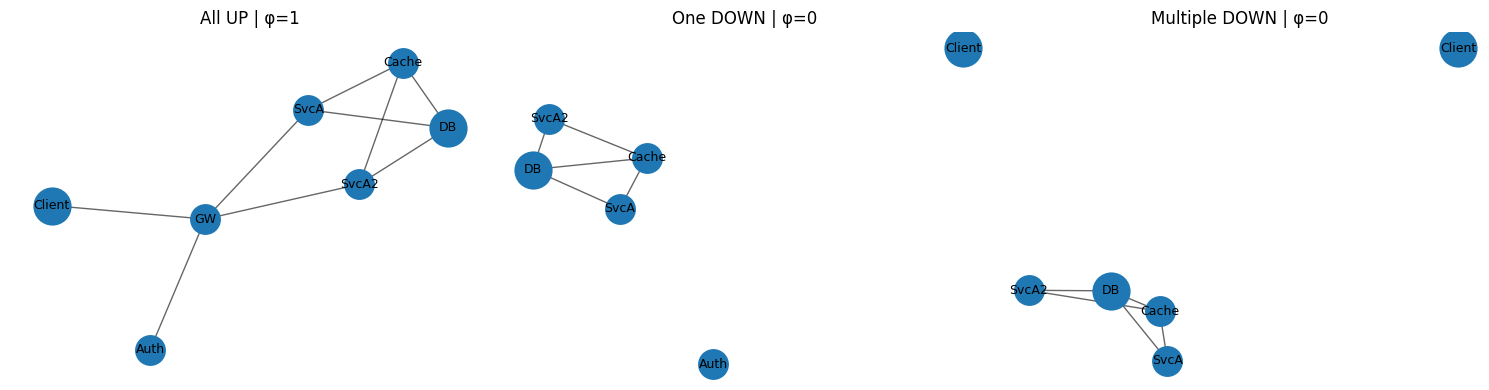

In [ ]:
# --- Demo residual graph evaluation ---

name, G, terminals = sample_topology("micro", seed=0)
repairable_nodes = [v for v in G.nodes() if v not in set(terminals)]
m = len(repairable_nodes)

criterion = "terminal_connectivity"
phi_fn = make_phi(criterion, terminals)

# Example states: all up, one down, several down
examples = {
    "All UP": np.ones(m, dtype=int),
    "One DOWN": None,
    "Multiple DOWN": None,
}

X_one = np.ones(m, dtype=int)
if m > 0:
    X_one[0] = 0
examples["One DOWN"] = X_one

X_multi = np.ones(m, dtype=int)
for i in range(min(2, m)):
    X_multi[i] = 0
examples["Multiple DOWN"] = X_multi

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (label, Xbits) in zip(axes, examples.items()):
    Gres = residual_graph(G, terminals, repairable_nodes, Xbits)
    val = phi_fn(Gres)
    draw_network_base(Gres, terminals=[t for t in terminals if t in Gres], ax=ax, title=f"{label} | φ={val}", seed=0)
plt.tight_layout()
plt.show()


## 5) State encoding, failure set \(\mathcal F\), and the Markov chain

We will build the exact Markov chain over \(S=2^{m}\) states, where \(m=|V_R|\).
To do that, we map states \(X\in\{0,1\}^m\) to integers \(s\in\{0,\dots,S-1\}\).

**Failure set:**  
\[
\mathcal F = \{ X : \phi(X)=0\}.
\]


In [ ]:
# --- State encoding utilities ---

def int_to_bits(s, m):
    # Little-endian bits
    return np.array([(s >> i) & 1 for i in range(m)], dtype=int)

def bits_to_int(bits):
    s = 0
    for i, b in enumerate(bits):
        s |= (int(b) & 1) << i
    return s

def enumerate_failure_mask(G, terminals, repairable_nodes, phi_fn):
    m = len(repairable_nodes)
    S = 1 << m
    fail = np.zeros(S, dtype=bool)
    for s in range(S):
        X = int_to_bits(s, m)
        Gres = residual_graph(G, terminals, repairable_nodes, X)
        fail[s] = (phi_fn(Gres) == 0)
    return fail


## 6) Transition matrix \(P(\pi)\) (exact)

Assumption: conditional independence of node transitions given current state.

For each repairable node \(v\):
- if UP: stays UP with prob \(1-p_v\), fails with prob \(p_v\)
- if DOWN: repaired with prob \(r_v(\pi_v)\), stays DOWN with prob \(1-r_v(\pi_v)\)

This produces a dense \(S\times S\) transition matrix in general, but is feasible for small \(m\le 10\).


In [ ]:
# --- Build transition matrix P(pi) ---

def build_transition_matrix(p_fail, r_repair):
    """Build P for independent per-node transitions.
    p_fail: array shape (m,) failure probability when UP
    r_repair: array shape (m,) repair probability when DOWN
    Returns P: shape (S,S)
    """
    m = len(p_fail)
    S = 1 << m
    P = np.zeros((S, S), dtype=float)

    # Precompute for each state s the per-bit prob of next bit given current bit
    for s in range(S):
        x = int_to_bits(s, m)
        # For each node i, prob(next=1) depends on x_i
        p1 = np.where(x == 1, 1.0 - p_fail, r_repair)
        p0 = 1.0 - p1

        # Iterate all next states y
        # For m<=10, S<=1024 => OK to do full enumeration
        for y in range(S):
            b = int_to_bits(y, m)
            prob = 1.0
            # product over i of p(b_i)
            # small m -> straightforward loop
            for i in range(m):
                prob *= p1[i] if b[i] == 1 else p0[i]
            P[s, y] = prob

        # Numerical stabilization: ensure row sums to 1
        rs = P[s].sum()
        if rs > 0:
            P[s] /= rs
        else:
            # Should not happen
            P[s, s] = 1.0
    return P


## 7) Hitting probability before horizon \(H\)

Define:
\[
h^{(t)}(s)=\Pr(\tau_{\mathcal F}\le t \mid X_0=s).
\]

Recursion:
- \(h^{(0)}(s)=\mathbf 1\{s\in\mathcal F\}\)
- \(h^{(t+1)}(s)=\mathbf 1\{s\in\mathcal F\}+\mathbf 1\{s\notin\mathcal F\}\sum_{y} P_{sy}(\pi)\, h^{(t)}(y)\)

We typically start from the all-UP state \(s_0\) (all repairable nodes UP).


In [ ]:
# --- Hitting probability DP ---

def hitting_probability(P, fail_mask, H):
    """Return h_H vector and full trajectory h_t (list of vectors).
    fail_mask: boolean array (S,), True on failure states
    """
    S = P.shape[0]
    h = fail_mask.astype(float).copy()  # h^(0)
    traj = [h.copy()]
    for _ in range(H):
        h_next = fail_mask.astype(float) + (~fail_mask).astype(float) * (P @ h)
        # clip for numerical stability
        h_next = np.clip(h_next, 0.0, 1.0)
        h = h_next
        traj.append(h.copy())
    return h, traj

def all_up_state(m):
    # all bits 1
    return (1 << m) - 1


## 8) Optimization: projected gradient descent under a budget

We solve:
\[
\min_{\pi}\; J(\pi)=h^{(H)}(s_0)\quad\text{s.t. }\pi\ge 0,\; c^\top\pi\le B.
\]

Baseline solver:
- finite-difference gradient on \(J(\pi)\)
- projected gradient descent onto the weighted simplex \(\{\pi\ge 0, c^\top\pi\le B\}\)

This is *not* the most efficient method, but it is simple, transparent, and serves as a strong baseline.


In [ ]:
# --- Projection onto weighted budget set: {pi>=0, sum c_i*pi_i <= B} ---

def project_weighted_budget(pi, c, B):
    """Euclidean projection onto {pi>=0, c·pi <= B}.
    Implemented by transforming y_i = c_i*pi_i and projecting y onto l1-ball (simplex) sum y <= B.
    Then pi_i = y_i / c_i.
    """
    pi = np.maximum(pi, 0.0)
    y = c * pi
    s = y.sum()
    if s <= B:
        return pi
    # Project y onto simplex sum y = B, y>=0
    u = np.sort(y)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - B))[0]
    if len(rho) == 0:
        theta = 0.0
    else:
        rho = rho[-1]
        theta = (cssv[rho] - B) / (rho + 1)
    y_proj = np.maximum(y - theta, 0.0)
    # Avoid divide-by-zero
    pi_proj = np.where(c > 0, y_proj / c, 0.0)
    return pi_proj

# --- Objective J(pi) ---

def compute_objective_J(G, terminals, criterion, params, pi, H, seed_layout=0):
    """Compute J(pi)=h^H(s0) for a given instance.
    params includes:
      - repairable_nodes
      - p_fail (m,)
      - c_cost (m,)
      - repair_model settings
      - criterion params (tau, ell, etc.)
    """
    repairable_nodes = params["repairable_nodes"]
    p_fail = params["p_fail"]
    c_cost = params["c_cost"]
    model = params["repair_model"]
    crit_params = params.get("criterion_params", {})

    # Build phi function
    phi_fn = make_phi(criterion, terminals, **crit_params)
    fail_mask = enumerate_failure_mask(G, terminals, repairable_nodes, phi_fn)

    # Repair probs from pi
    if model["type"] == "concave":
        r = repair_prob_concave(pi, a=model.get("a", 2.0), r0=model.get("r0", 0.0))
    elif model["type"] == "linear":
        r = repair_prob_linear_sat(pi, beta=model.get("beta", 0.5), r0=model.get("r0", 0.0))
    else:
        raise ValueError("Unknown repair model")

    P = build_transition_matrix(p_fail, r)
    m = len(repairable_nodes)
    s0 = all_up_state(m)
    hH, _ = hitting_probability(P, fail_mask, H)
    return float(hH[s0])

def finite_diff_grad(G, terminals, criterion, params, pi, H, eps=1e-3):
    base = compute_objective_J(G, terminals, criterion, params, pi, H)
    g = np.zeros_like(pi)
    for i in range(len(pi)):
        pi2 = pi.copy()
        pi2[i] += eps
        g[i] = (compute_objective_J(G, terminals, criterion, params, pi2, H) - base) / eps
    return base, g

def projected_gradient_descent(G, terminals, criterion, params, H, B,
                              lr=0.5, iters=30, eps=1e-3, verbose=True):
    m = len(params["repairable_nodes"])
    c = params["c_cost"]
    # init: uniform spending
    pi = np.ones(m) * (B / (c.sum() + 1e-12))
    pi = project_weighted_budget(pi, c, B)

    history = []
    for t in range(iters):
        J, g = finite_diff_grad(G, terminals, criterion, params, pi, H, eps=eps)
        history.append(J)
        # gradient step
        pi = pi - lr * g
        # projection
        pi = project_weighted_budget(pi, c, B)
        if verbose and (t % max(1, iters//10) == 0 or t == iters-1):
            print(f"iter {t:02d} | J={J:.4f} | budget used={(c@pi):.3f}/{B}")
    return pi, np.array(history)


## 9) Visualization: policy \(\pi\) on the network

We overlay the optimized \(\pi\) on the graph:
- node size and color are proportional to \(\pi_v\)
- terminals are highlighted

This makes the result interpretable: **where does the solver spend the repair budget?**


iter 00 | J=0.4312 | budget used=2.500/2.5
iter 20 | J=0.4312 | budget used=2.500/2.5
iter 40 | J=0.4311 | budget used=2.500/2.5
iter 60 | J=0.4311 | budget used=2.500/2.5
iter 80 | J=0.4311 | budget used=2.500/2.5
iter 100 | J=0.4311 | budget used=2.500/2.5
iter 120 | J=0.4311 | budget used=2.500/2.5
iter 140 | J=0.4310 | budget used=2.500/2.5
iter 160 | J=0.4310 | budget used=2.500/2.5
iter 180 | J=0.4310 | budget used=2.500/2.5
iter 199 | J=0.4310 | budget used=2.500/2.5


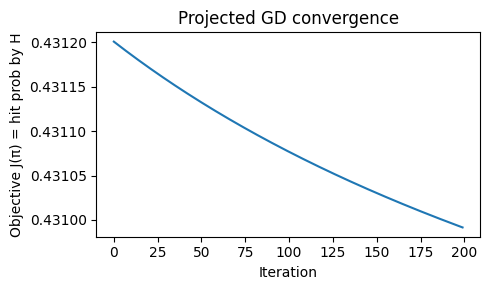

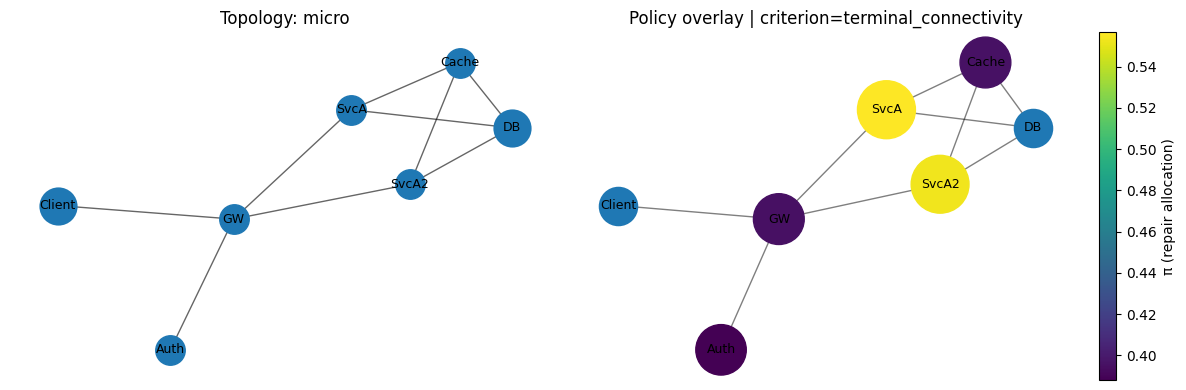

In [ ]:
# --- Build a single instance and solve it (end-to-end demo) ---

# Choose topology and criterion
name, G, terminals = sample_topology("micro", seed=0)
term_set = set(terminals)
repairable_nodes = [v for v in G.nodes() if v not in term_set]
m = len(repairable_nodes)
assert m <= 10, "For exact Markov chain, keep repairable nodes ≤ 10."

# Parameters (students can change these)
rng = np.random.default_rng(0)
p_fail = rng.uniform(0.01, 0.08, size=m)     # per-step failure probs
c_cost = rng.uniform(0.8, 1.2, size=m)       # per-node repair cost weights

params = {
    "repairable_nodes": repairable_nodes,
    "p_fail": p_fail,
    "c_cost": c_cost,
    "repair_model": {"type": "concave", "a": 2.0, "r0": 0.02},
    # criterion-specific knobs (examples below)
    "criterion_params": {}
}

criterion = "terminal_connectivity"
H = 10
B = 2.5

# Solve
pi_opt, hist = projected_gradient_descent(G, terminals, criterion, params, H=H, B=B,
                                          lr=0.8, iters=200, eps=2e-3, verbose=True)

# Map π back to nodes
pi_by_node = {repairable_nodes[i]: float(pi_opt[i]) for i in range(m)}
for t in terminals:
    pi_by_node[t] = 0.0  # terminals not repairable

# Plot convergence
plt.figure(figsize=(5,3))
plt.plot(hist)
plt.xlabel("Iteration")
plt.ylabel("Objective J(π) = hit prob by H")
plt.title("Projected GD convergence")
plt.tight_layout()
plt.show()

# Visualize topology + policy
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
draw_network_base(G, terminals, ax=ax[0], title=f"Topology: {name}", seed=0)
draw_policy_on_network(G, terminals, pi_by_node, ax=ax[1], title=f"Policy overlay | criterion={criterion}", seed=0)
plt.tight_layout()
plt.show()


## 10) Comparative analysis (criteria, budgets, topologies)

We now compare how the optimal policy changes:
- across different **criteria** \(\phi\)
- across different **budgets** \(B\)
- across different **topologies**

This is where the benchmark becomes informative: *the same network* can yield very different policies depending on what “UP” means.


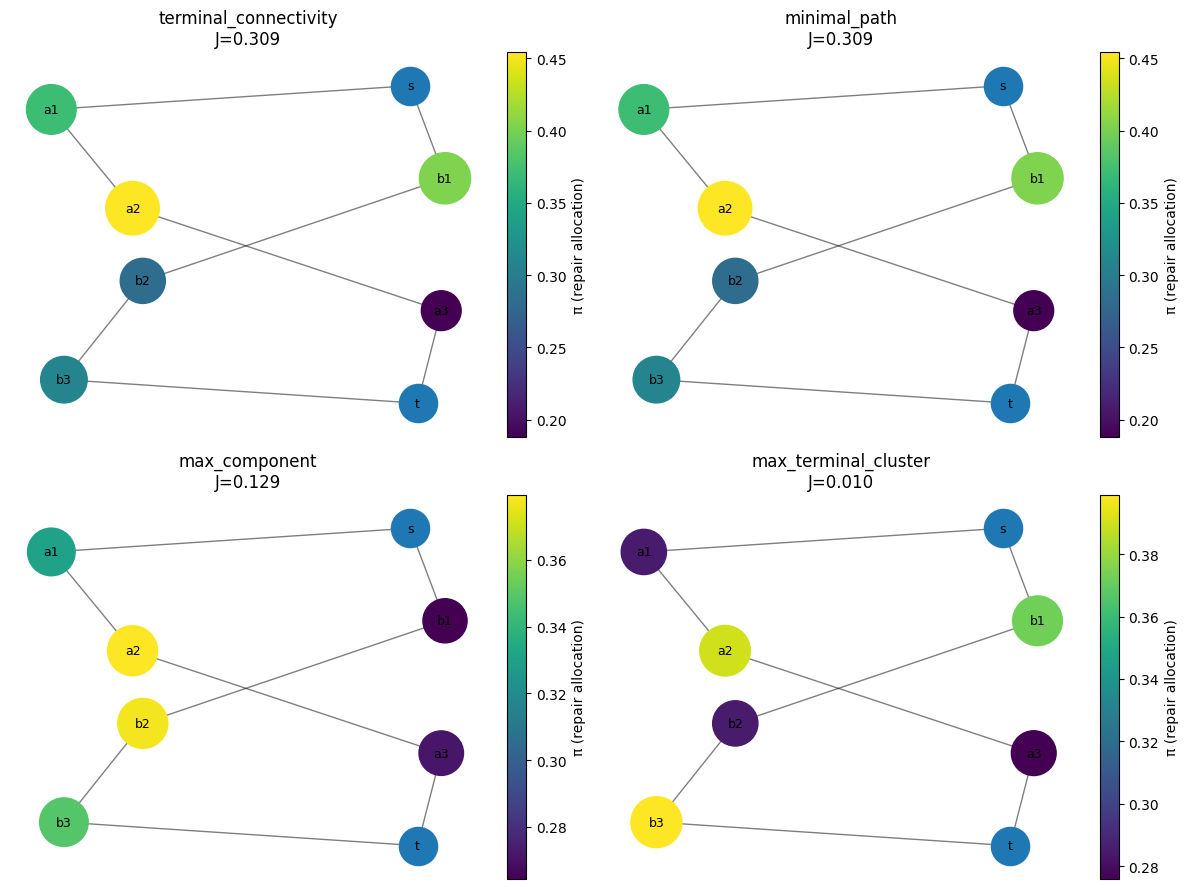

In [ ]:
# --- Comparative analysis helper ---

def solve_instance(G, terminals, criterion, params, H, B, seed=0, iters=25):
    pi_opt, hist = projected_gradient_descent(G, terminals, criterion, params, H=H, B=B,
                                              lr=0.8, iters=iters, eps=2e-3, verbose=False)
    J = compute_objective_J(G, terminals, criterion, params, pi_opt, H=H)
    pi_by_node = {params["repairable_nodes"][i]: float(pi_opt[i]) for i in range(len(pi_opt))}
    for t in terminals:
        pi_by_node[t] = 0.0
    return pi_opt, pi_by_node, J, hist

def make_default_params(G, terminals, seed=0):
    term_set = set(terminals)
    repairable_nodes = [v for v in G.nodes() if v not in term_set]
    m = len(repairable_nodes)
    rng = np.random.default_rng(seed)
    p_fail = rng.uniform(0.01, 0.08, size=m)
    c_cost = rng.uniform(0.8, 1.2, size=m)
    return {
        "repairable_nodes": repairable_nodes,
        "p_fail": p_fail,
        "c_cost": c_cost,
        "repair_model": {"type": "concave", "a": 2.0, "r0": 0.02},
        "criterion_params": {}
    }

# Choose one topology, compare criteria
name, G, terminals = sample_topology("parallel", seed=1)
params = make_default_params(G, terminals, seed=1)

H = 10
B = 2.0

criteria = [
    ("terminal_connectivity", {}),
    ("minimal_path", {"ell": 4}),  # threshold on path length between the two terminals
    ("max_component", {"tau": max(3, G.number_of_nodes()//2)}),
    ("max_terminal_cluster", {"tau": 3}),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, (crit, crit_params) in zip(axes, criteria):
    params["criterion_params"] = crit_params
    pi_opt, pi_by_node, J, hist = solve_instance(G, terminals, crit, params, H=H, B=B, iters=20)
    draw_policy_on_network(G, terminals, pi_by_node, ax=ax, title=f"{crit}\nJ={J:.3f}", seed=0)

plt.tight_layout()
plt.show()


### Budget sweep (same topology, same criterion)

We vary the budget and observe how:
- the objective decreases,
- the policy becomes more spread or more concentrated.


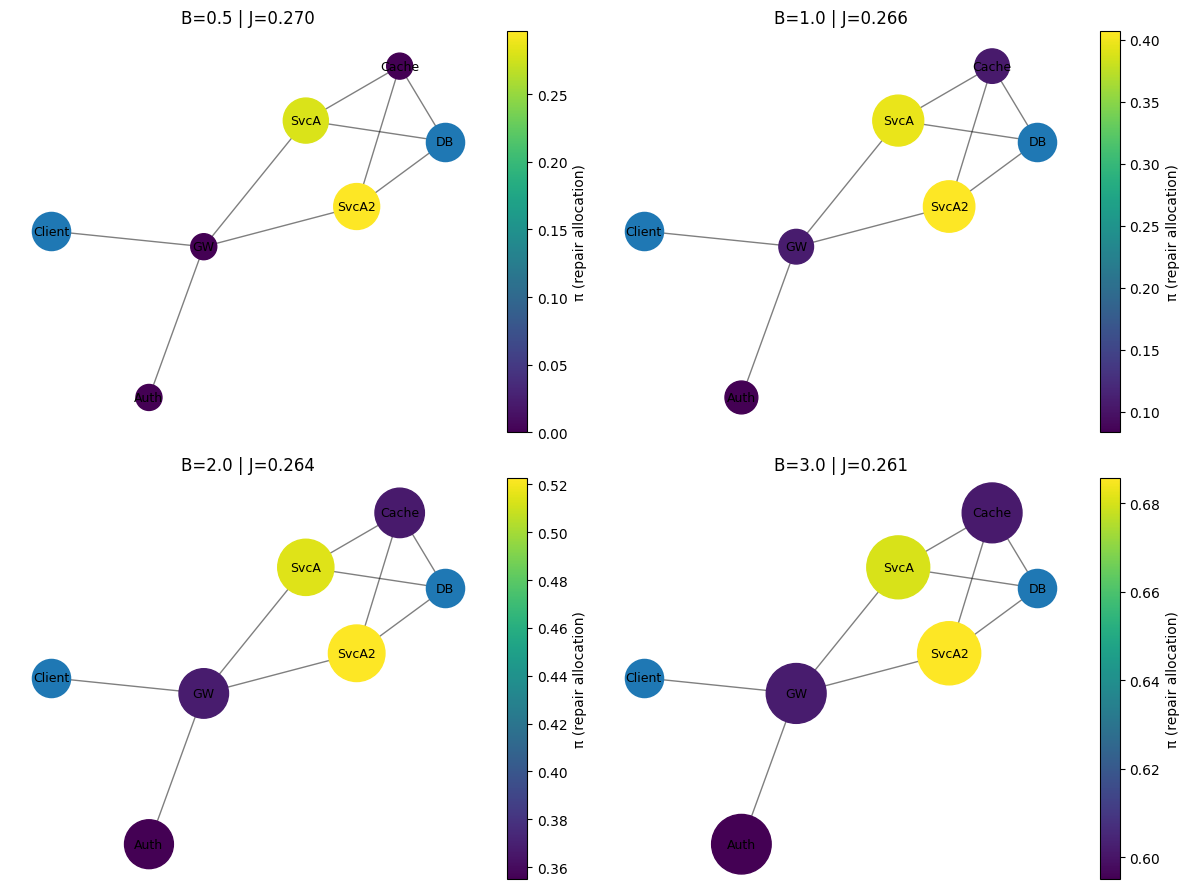

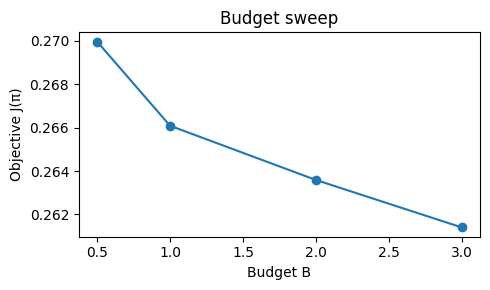

In [ ]:
# --- Budget sweep ---

name, G, terminals = sample_topology("micro", seed=2)
params = make_default_params(G, terminals, seed=2)
criterion = "terminal_connectivity"
H = 10

budgets = [0.5, 1.0, 2.0, 3.0]
Js = []

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, B in zip(axes, budgets):
    pi_opt, pi_by_node, J, hist = solve_instance(G, terminals, criterion, params, H=H, B=B, iters=20)
    Js.append(J)
    draw_policy_on_network(G, terminals, pi_by_node, ax=ax, title=f"B={B} | J={J:.3f}", seed=0)

plt.tight_layout()
plt.show()

plt.figure(figsize=(5,3))
plt.plot(budgets, Js, marker='o')
plt.xlabel("Budget B")
plt.ylabel("Objective J(π)")
plt.title("Budget sweep")
plt.tight_layout()
plt.show()


## 11) Dataset generation for Learning-to-Optimize

We generate a dataset of optimization instances:

\[
(\text{topology},\; T,\; p_v,\; c_v,\; \text{criterion},\; B,\; H) \mapsto \pi^\star
\]

We store:
- adjacency list (edges)
- terminals
- node list + which nodes are repairable
- parameters \(p\), \(c\), repair model knobs
- criterion and its parameters
- \(\pi^\star\) and achieved objective \(J(\pi^\star)\)

This dataset can later be used to train neural networks (L2O / GNN, etc.).


In [ ]:
# --- Dataset generation ---

import json
from datetime import datetime

def graph_to_serializable(G):
    return {
        "nodes": list(G.nodes()),
        "edges": [(u, v) for (u, v) in G.edges()],
        "is_directed": G.is_directed(),
    }

def generate_dataset(n_instances=30, seed=0, H=10, budgets=(0.5, 1.0, 2.0), criteria=None):
    if criteria is None:
        criteria = [
            ("terminal_connectivity", {}),
            ("minimal_path", {"ell": 4}),
            ("max_component", {"tau": 4}),
            ("max_terminal_cluster", {"tau": 3}),
        ]
    rng = np.random.default_rng(seed)
    data = []
    topo_names = list(TOPO_CATALOG.keys())

    for k in range(n_instances):
        topo = rng.choice(topo_names)
        _, G, terminals = sample_topology(topo, seed=int(rng.integers(0, 10_000)))

        # Keep only instances with small repairable set
        repairable_nodes = [v for v in G.nodes() if v not in set(terminals)]
        if len(repairable_nodes) > 10:
            continue

        params = make_default_params(G, terminals, seed=int(rng.integers(0, 10_000)))

        crit, crit_params = criteria[int(rng.integers(0, len(criteria)))]
        params["criterion_params"] = crit_params

        B = float(rng.choice(budgets))

        # Solve baseline (keep iters modest for dataset gen)
        pi_opt, _, J, _ = solve_instance(G, terminals, crit, params, H=H, B=B, iters=20)

        record = {
            "topology": topo,
            "graph": graph_to_serializable(G),
            "terminals": list(terminals),
            "repairable_nodes": params["repairable_nodes"],
            "p_fail": params["p_fail"].tolist(),
            "c_cost": params["c_cost"].tolist(),
            "repair_model": params["repair_model"],
            "criterion": crit,
            "criterion_params": crit_params,
            "H": int(H),
            "B": float(B),
            "pi_star": pi_opt.tolist(),
            "J_pi_star": float(J),
        }
        data.append(record)
    return data

dataset = generate_dataset(n_instances=40, seed=0, H=10)
print(f"Generated {len(dataset)} instances")

out_path = "repair_allocation_benchmark_small.json"
with open(out_path, "w") as f:
    json.dump({"generated_at": datetime.utcnow().isoformat(), "instances": dataset}, f, indent=2)

print(f"Saved dataset to: {out_path}")


Generated 40 instances
Saved dataset to: repair_allocation_benchmark_small.json


/tmp/ipython-input-3015570745.py:67: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  json.dump({"generated_at": datetime.utcnow().isoformat(), "instances": dataset}, f, indent=2)


## 12) Sanity checks and discussion

Typical sanity checks:
- Increasing budget **should not increase** the hitting probability.
- Redundant topologies (parallel paths) should be more robust than pure series chains.
- Policies should shift depending on the criterion \(\phi\).

At this point, you have:
- a generator of instances (topology + criterion),
- a baseline solver (projected GD),
- network visualizations of the resulting repair policies,
- a dataset format for downstream Learning-to-Optimize models.
